In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [6]:
df = pd.read_csv("ev_charging_dataset.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

features = [
    "timestamp",
    "vehicle_type",
    "energy_consumed_kWh",
    "charging_power_kW",
    "station_load",
    "queue_length",
    "electricity_price"
]

df = df[features]

print(df.head())

Dataset Shape: (8354, 7)

Columns:
Index(['timestamp', 'vehicle_type', 'energy_consumed_kWh', 'charging_power_kW',
       'queue_length', 'station_load', 'electricity_price'],
      dtype='object')
             timestamp vehicle_type  energy_consumed_kWh  charging_power_kW  \
0  2025-01-01 00:00:00  Two-Wheeler            30.528616                  7   
1  2025-01-01 00:15:00  Two-Wheeler            41.504507                 50   
2  2025-01-01 00:30:00          Car            45.016306                 50   
3  2025-01-01 00:45:00  Two-Wheeler            28.291670                 11   
4  2025-01-01 01:00:00  Two-Wheeler            55.810835                 11   

   station_load  queue_length  electricity_price  
0     15.161672             4              13.66  
1     20.997219             3               5.47  
2     31.606151             8               9.50  
3     21.803050             3               6.22  
4     15.626266             5              13.42  


In [8]:
# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort according to time
df = df.sort_values("timestamp")

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove missing values
df = df.dropna()

print("\nDataset after preprocessing:")
print(df.head())



Missing Values:
timestamp              0
vehicle_type           0
energy_consumed_kWh    0
charging_power_kW      0
station_load           0
queue_length           0
electricity_price      0
dtype: int64

Dataset after preprocessing:
            timestamp vehicle_type  energy_consumed_kWh  charging_power_kW  \
0 2025-01-01 00:00:00  Two-Wheeler            30.528616                  7   
1 2025-01-01 00:15:00  Two-Wheeler            41.504507                 50   
2 2025-01-01 00:30:00          Car            45.016306                 50   
3 2025-01-01 00:45:00  Two-Wheeler            28.291670                 11   
4 2025-01-01 01:00:00  Two-Wheeler            55.810835                 11   

   station_load  queue_length  electricity_price  
0     15.161672             4              13.66  
1     20.997219             3               5.47  
2     31.606151             8               9.50  
3     21.803050             3               6.22  
4     15.626266             5            

In [9]:
#encoding
df = pd.get_dummies(
    df,
    columns=["vehicle_type"],
    dtype=int
)

print("\nColumns after encoding:")
print(df.columns)


Columns after encoding:
Index(['timestamp', 'energy_consumed_kWh', 'charging_power_kW', 'station_load',
       'queue_length', 'electricity_price', 'vehicle_type_Bus',
       'vehicle_type_Car', 'vehicle_type_Two-Wheeler'],
      dtype='object')


In [10]:
vehicle_columns = [
    col for col in df.columns
    if col.startswith("vehicle_type_")
]

feature_columns = [
    "energy_consumed_kWh",
    "charging_power_kW",
    "queue_length",
    "electricity_price"
]

feature_columns += vehicle_columns

target_column = "station_load"

X = df[feature_columns]
y = df[target_column]

print("\nInput Features:")
print(feature_columns)

print("\nTarget:")
print(target_column)

print("\nX Shape:", X.shape)
print("Y Shape:", y.shape)


Input Features:
['energy_consumed_kWh', 'charging_power_kW', 'queue_length', 'electricity_price', 'vehicle_type_Bus', 'vehicle_type_Car', 'vehicle_type_Two-Wheeler']

Target:
station_load

X Shape: (8354, 7)
Y Shape: (8354,)


In [11]:
# train-test and split
split = int(len(df) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 6683
Testing samples: 1671


In [15]:
# scaling the data
from sklearn.preprocessing import MinMaxScaler

# Create scalers
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

# Scale input features
X_train_scaled = feature_scaler.fit_transform(X_train)
X_test_scaled = feature_scaler.transform(X_test)

# Scale target
y_train_scaled = target_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
)

y_test_scaled = target_scaler.transform(
    y_test.values.reshape(-1, 1)
)

print("X_train_scaled shape:", X_train_scaled.shape)
print("y_train_scaled shape:", y_train_scaled.shape)

X_train_scaled shape: (6683, 7)
y_train_scaled shape: (6683, 1)


In [18]:
# create time series sequence
import numpy as np

def create_sequences(X, y, time_steps=24):

    X_sequences = []
    y_sequences = []

    for i in range(time_steps, len(X)):

        X_sequences.append(
            X[i-time_steps:i]
        )

        y_sequences.append(
            y[i]
        )

    return np.array(X_sequences), np.array(y_sequences)



time_steps = 24

X_train_seq, y_train_seq = create_sequences(
    X_train_scaled,
    y_train_scaled,
    time_steps
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled,
    y_test_scaled,
    time_steps
)

print("X Train Shape:", X_train_seq.shape)
print("Y Train Shape:", y_train_seq.shape)

print("X Test Shape:", X_test_seq.shape)
print("Y Test Shape:", y_test_seq.shape)

X Train Shape: (6659, 24, 7)
Y Train Shape: (6659, 1)
X Test Shape: (1647, 24, 7)
Y Test Shape: (1647, 1)


In [19]:
#  building lstm model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()

model.add(
    LSTM(
        64,
        return_sequences=True,
        input_shape=(
            X_train_seq.shape[1],
            X_train_seq.shape[2]
        )
    )
)

model.add(Dropout(0.2))

model.add(
    LSTM(32)
)

model.add(Dropout(0.2))

model.add(
    Dense(16, activation="relu")
)

model.add(
    Dense(1)
)

model.summary()

C:\Users\Akshada\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 64)         │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,393 (122.63 KB)

 Trainable params: 31,393 (122.63 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
model.compile(
    optimizer="adam",
    loss="mse"
)
print("Model compiled successfully.")

Model compiled successfully.


In [23]:
history = model.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - loss: 0.1007 - val_loss: 0.1049
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - loss: 0.0939 - val_loss: 0.0989
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0917 - val_loss: 0.1011
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 0.0913 - val_loss: 0.1001
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.0902 - val_loss: 0.1001
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0890 - val_loss: 0.0975
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - loss: 0.0892 - val_loss: 0.0996
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0883 - val_loss: 0.0984
Epoch 9/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0881 - val_loss: 0.0999
Epoch 10/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.0867 - val_loss: 0.0999
Epoch 11/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0852 - val_loss: 0.0988
Epoch 12/30
188/188 ━━━━━━━━━━━━━━━━━━━━

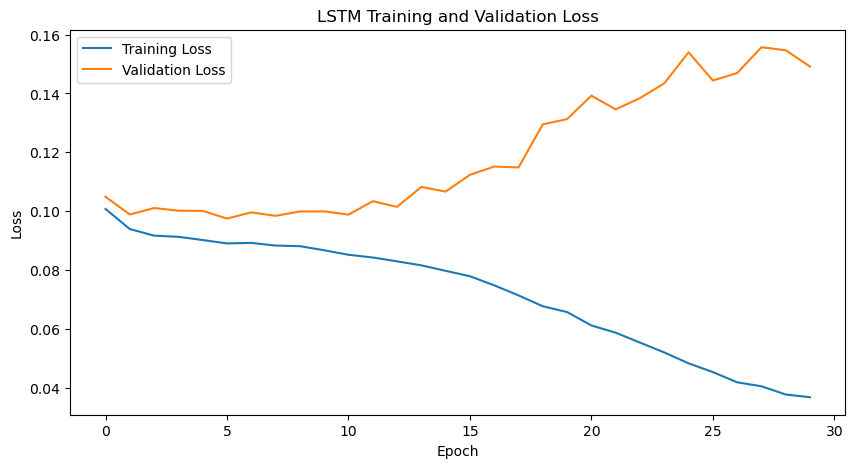

In [24]:
# plots
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training and Validation Loss")

plt.legend()

plt.show()

In [26]:
predictions = model.predict(X_test_seq)

print("Prediction shape:", predictions.shape)

predictions_actual = target_scaler.inverse_transform(
    predictions
)

y_test_actual = target_scaler.inverse_transform(
    y_test_seq
)

print("First 5 actual values:")
print(y_test_actual[:5])

print("\nFirst 5 predicted values:")
print(predictions_actual[:5])

52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
Prediction shape: (1647, 1)
First 5 actual values:
[[67.30325733]
 [87.29189478]
 [80.11739848]
 [74.33441128]
 [82.68687738]]

First 5 predicted values:
[[40.11409 ]
 [38.851757]
 [38.89256 ]
 [38.85158 ]
 [39.952118]]


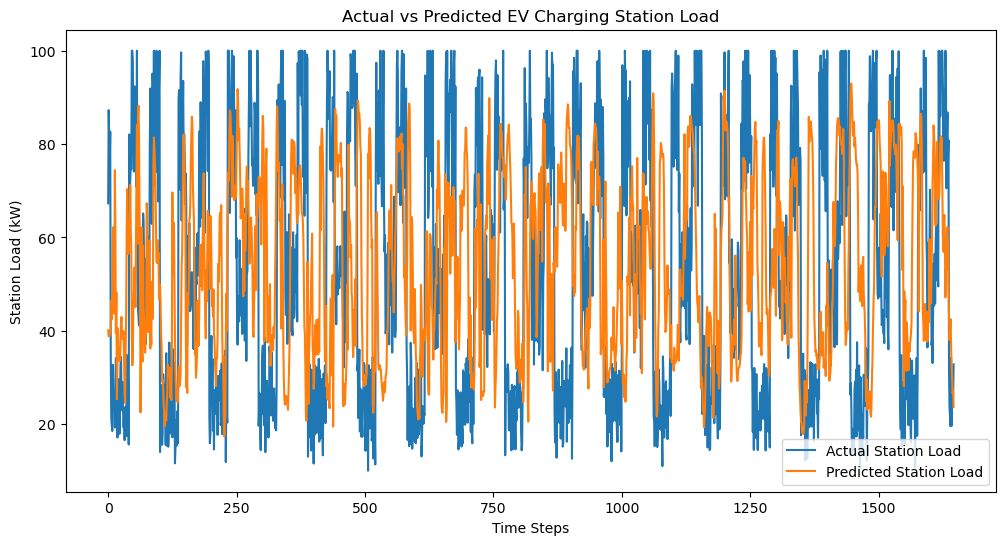

In [29]:
plt.figure(figsize=(12, 6))

plt.plot(
    y_test_actual,
    label="Actual Station Load"
)

plt.plot(
    predictions_actual,
    label="Predicted Station Load"
)

plt.xlabel("Time Steps")
plt.ylabel("Station Load (kW)")

plt.title(
    "Actual vs Predicted EV Charging Station Load"
)

plt.legend()

plt.show()